In [1]:
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import MinMaxScaler,LabelEncoder,OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv("C:\\Users\\WELCOME\\OneDrive\\Desktop\\ML\\Extended_Employee_Performance_and_Productivity_Data.csv")
df.head()

,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,1,IT,Male,55,Specialist,2022-01-19 08:03:05.556036,2,High School,5,6750.0,33,32,22,2,0,14,66,0,2.63,False
1,2,Finance,Male,29,Developer,2024-04-18 08:03:05.556036,0,High School,5,7500.0,34,34,13,14,100,12,61,2,1.72,False
2,3,Finance,Male,55,Specialist,2015-10-26 08:03:05.556036,8,High School,3,5850.0,37,27,6,3,50,10,1,0,3.17,False
3,4,Customer Support,Female,48,Analyst,2016-10-22 08:03:05.556036,7,Bachelor,2,4800.0,52,10,28,12,100,10,0,1,1.86,False
4,5,Engineering,Female,36,Analyst,2021-07-23 08:03:05.556036,3,Bachelor,2,4800.0,38,11,29,13,100,15,9,1,1.25,False


In [3]:
X = df.drop(columns=['Monthly_Salary'])
y= df['Monthly_Salary']

In [4]:
num_cols=X.select_dtypes(include='number').columns
obj_cols=X.select_dtypes(include='object').columns

In [5]:
num_cols

Index(['Employee_ID', 'Age', 'Years_At_Company', 'Performance_Score',
       'Work_Hours_Per_Week', 'Projects_Handled', 'Overtime_Hours',
       'Sick_Days', 'Remote_Work_Frequency', 'Team_Size', 'Training_Hours',
       'Promotions', 'Employee_Satisfaction_Score'],
      dtype='object')

In [6]:
obj_cols


Index(['Department', 'Gender', 'Job_Title', 'Hire_Date', 'Education_Level'], dtype='object')

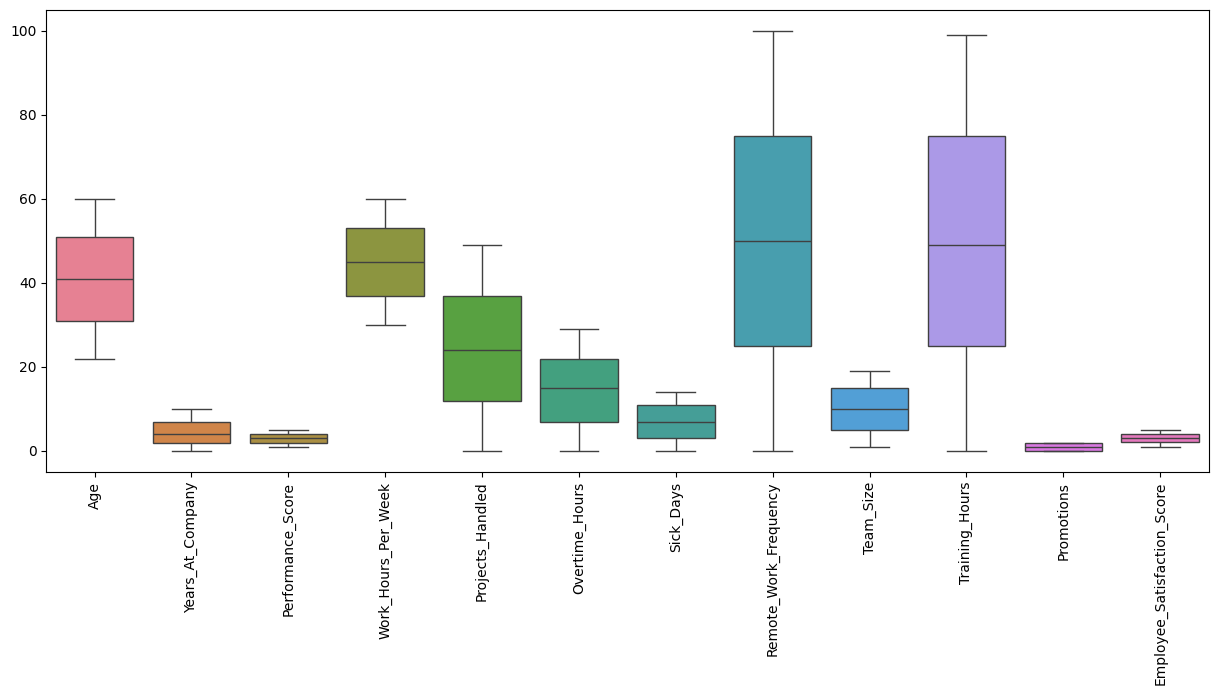

In [7]:
num_cols=num_cols.drop('Employee_ID')

import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))
sns.boxplot(data = X[num_cols])
plt.xticks(rotation=90)
plt.show()

#### Split the data

In [8]:
from sklearn.model_selection import train_test_split

xtrain,xtest,ytrain,ytest=train_test_split(X,y,train_size=0.8,random_state=42)

Scale the numeric column

In [9]:
from sklearn.preprocessing import MinMaxScaler

scale = MinMaxScaler()

xtrain[num_cols] = scale.fit_transform(xtrain[num_cols])
xtest[num_cols] = scale.fit_transform(xtest[num_cols])


Encode the categorical value

In [11]:
xtrain = xtrain.drop(columns='Hire_Date')
xtest = xtest.drop(columns='Hire_Date')

obj_cols = xtrain.select_dtypes(include='object').columns

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False,handle_unknown='ignore')

train_values = encoder.fit_transform(xtrain[obj_cols])
train_cols = encoder.get_feature_names_out(obj_cols)

xtrain[train_cols] = train_values
xtrain.drop(columns=obj_cols,inplace=True)

test_values = encoder.fit_transform(xtest[obj_cols])
test_cols = encoder.get_feature_names_out(obj_cols)

xtest[train_cols] = test_values
xtest.drop(columns=obj_cols,inplace=True)

## Train the model

In [12]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(xtrain,ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


#Check Accuracy

In [13]:
print(model.score(xtrain,ytrain))
print(model.score(xtest,ytest))

0.9913557226969272
0.9914012231111459


# Evaluate the model

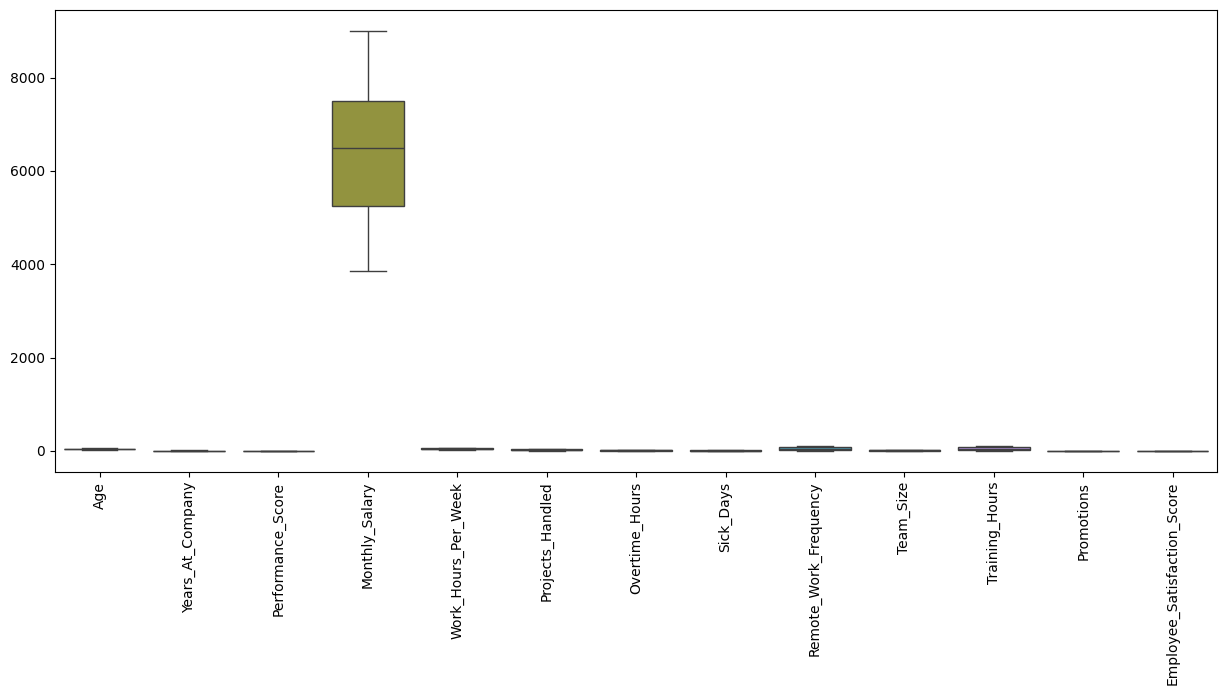

In [15]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
num_cols = num_cols.drop('Employee_ID')

plt.figure(figsize=(15,6))
sns.boxplot(data = df[num_cols])
plt.xticks(rotation=90)
plt.show()